# Economic charting with `ggplot2` in R

In [6]:
# Load necessary libraries
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(tidyr))
suppressPackageStartupMessages(library(magrittr))
suppressPackageStartupMessages(library(lubridate))
suppressPackageStartupMessages(library(stringr))
suppressPackageStartupMessages(library(gridExtra))

suppressPackageStartupMessages(library(quantmod))

In [2]:
# Set plot dimensions to 3.9*2 x 3.2 inches
options(repr.plot.width = 3.9, repr.plot.height = 3.2)  # in inches

# Bar Chart
I will be plotting the annual returns of the S&P 500 from Yahoo Finance.

In [3]:
# Load in SPX data from Yahoo Finance
getSymbols(c("^GSPC"), src = "yahoo", from = "2000-01-01")
# head(GSPC)
tail(GSPC)

[1] "GSPC"

           GSPC.Open GSPC.High GSPC.Low GSPC.Close GSPC.Volume GSPC.Adjusted
2025-11-13   6826.47   6828.05  6724.72    6737.49  5473720000       6737.49
2025-11-14   6672.14   6774.31  6646.87    6734.11  5042660000       6734.11
2025-11-17   6713.61   6754.50  6638.90    6672.41  5204220000       6672.41
2025-11-18   6641.19   6666.63  6574.32    6617.32  5159390000       6617.32
2025-11-19   6625.84   6689.75  6603.50    6642.16  5021610000       6642.16
2025-11-20   6737.93   6770.35  6534.05    6538.76  5596080000       6538.76

I will take closing prices at the start and end of each year returned by the `quantmod` library. Then, I will calculate the annual return using last year's close price and this year's close price.

In [4]:
# Calculate the annual return year each year
df <- data.frame(date = index(GSPC), coredata(GSPC))
df_year <- df %>% 
select(date, GSPC.Close) %>%
arrange(date) %>%
na.omit() %>%
mutate(year = year(date)) %>% 
group_by(year) %>% 
slice(c(1, n())) %>% 
reframe(pct_chg = (last(GSPC.Close) - first(GSPC.Close)) / first(GSPC.Close) * 100)

# View table of annual returns
head(df_year)
# tail(df_year)

# Since 2000, the average annual return of the S&P 500 is 7%
mean(df_year$pct_chg, na.rm = TRUE)


year,pct_chg
<dbl>,<dbl>
2000,-9.272821
2001,-10.534810
2002,-23.803340
2003,22.319396
2004,9.331703
2005,3.844177


[1] 7.10389

Now I will plot the annual return for each year in a bar chart.

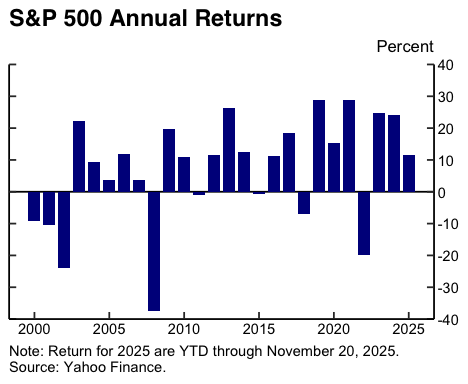

In [5]:
stocks <- df_year %>% ggplot() + 
  geom_hline(yintercept = 0, linewidth = 0.5, color = "black") +
  geom_col(aes(x = year, y = pct_chg), fill = "darkblue", width = 0.8) +
  scale_x_continuous(breaks = seq(1990, 2025, by = 5)) +
  scale_y_continuous(
    position = "right",
    sec.axis = dup_axis(labels = NULL),
    breaks = seq(-40, 40, by = 10),
    limits = c(-40, 40),
    expand = c(0, 0)
    ) +
  xlab(NULL) + ylab(NULL) +
  labs(
    title = "S&P 500 Annual Returns", 
    subtitle = "Percent", 
    caption = paste0(
      "Note: Return for 2025 are YTD through ", format(max(df$date), "%B %d, %Y"),".",
      "\nSource: Yahoo Finance.")
    ) +
  theme_classic() +
  theme(
      plot.title = element_text(family = "Helvetica", face = "bold", size = 14),
      plot.subtitle = element_text(hjust = 1, size = 10),
      axis.text = element_text(color = "black"),
      axis.ticks.length = unit(-0.15, "cm"),
      plot.caption = element_text(hjust = 0)
      )
      
stocks

ggsave("../plots/stocks.png", plot = stocks, width = 3.9, height = 3.2+(0.13*2), units = "in", dpi = 300)